In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set()
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('../data/gym_churn_us_clean.csv')
data.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,frequency_drop,age_group
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,0.020398,26-35
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,0.012693,26-35
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,0.122596,26-35
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,-0.151582,26-35
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,-0.006194,26-35


Checking the correlation between parameters

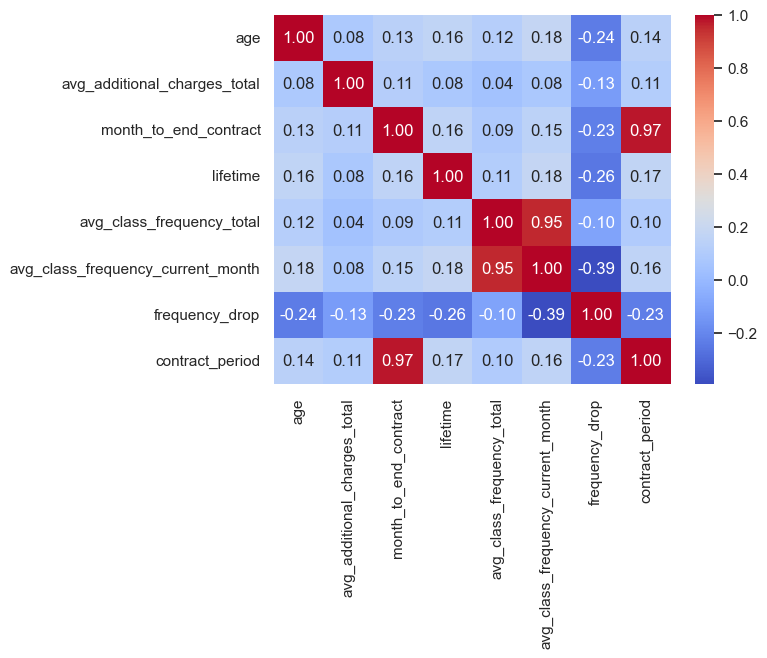

In [3]:
corr = data[["age", "avg_additional_charges_total", "month_to_end_contract", "lifetime", "avg_class_frequency_total", "avg_class_frequency_current_month", "frequency_drop", "contract_period"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Dropping columns with high correlation rate to prevent multicollinearity. Also dropping gender and phone classes, since they are not effective enough to use. Dropping age columns because we will use age group as a categorical parameter

In [4]:
data = data.drop(columns=[
   "age","month_to_end_contract","avg_class_frequency_total","avg_class_frequency_current_month","gender","phone"])

Creating dummy columns for contract_period and age_group parameters

In [5]:
data.dtypes

near_location                     int64
partner                           int64
promo_friends                     int64
contract_period                   int64
group_visits                      int64
avg_additional_charges_total    float64
lifetime                          int64
churn                             int64
frequency_drop                  float64
age_group                        object
dtype: object

In [6]:
data['contract_period'] = data['contract_period'].astype("category")
data['age_group'] = data['age_group'].astype("category")

In [7]:
data_dummy = pd.get_dummies(data, columns=['contract_period','age_group'], drop_first=True, dtype=int)

In [9]:
data_dummy.columns

Index(['near_location', 'partner', 'promo_friends', 'group_visits',
       'avg_additional_charges_total', 'lifetime', 'churn', 'frequency_drop',
       'contract_period_6', 'contract_period_12', 'age_group_26-35',
       'age_group_36+'],
      dtype='object')

Variance Inflation Factor test

In [16]:
X = data_dummy.drop(columns=['churn'])
X = sm.add_constant(X)

vif_table = pd.DataFrame()
vif_table['variables'] = X.columns
vif_table['VIF'] = [
    variance_inflation_factor(X, i)
    for i in range(X.shape[1])
    ]

vif_table.sort_values(by="VIF", ascending=False)

,variables,VIF
0,const,17.011972
2,partner,1.361447
3,promo_friends,1.354482
9,contract_period_12,1.331169
10,age_group_26-35,1.203475
8,contract_period_6,1.174344
11,age_group_36+,1.170533
7,frequency_drop,1.154608
6,lifetime,1.099781
1,near_location,1.096904


In [10]:
data_dummy.to_csv("../data/gym_churn_us_dummy.csv", index=False)